# Quantifying Noise Impact on Bell States

## Overview
Bell states are maximally entangled two-qubit states and are highly sensitive to decoherence and gate errors. In this notebook we quantify how controlled noise levels degrade Bell-state quality.

We use two metrics:
1. **State fidelity** with respect to $|\Phi^+\rangle$,
$
F = \langle \Phi^+ | \rho_{\text{noisy}} | \Phi^+ \rangle,
$
where $\rho_{\text{noisy}}$ is the noisy output state.
2. **Measurement error leakage**, measured by probability mass in undesired outcomes `01` and `10`.

In this experiment you will:
- Build a Bell-state preparation circuit.
- Sweep depolarizing noise strength.
- Compute fidelity and leakage metrics.
- Visualize how entanglement quality degrades as noise increases.

**Prerequisites:** Bell states, density matrices, and basic noise-channel concepts.

**Qiskit version pin:** `qiskit==2.3.0` (Aer simulators via `qiskit_aer`).

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

print(f"Qiskit version: {qiskit.__version__}")
print("Using Aer density-matrix and shot-based simulators.")

Qiskit version: 2.3.0
Using Aer density-matrix and shot-based simulators.


## Build the Bell-state circuit and ideal target state

In [2]:
def build_bell_preparation_circuit() -> QuantumCircuit:
    """Construct a circuit that prepares |Phi+> from |00>."""
    bell = QuantumCircuit(2)
    bell.h(0)
    bell.cx(0, 1)
    bell.barrier(label='Bell state prepared')
    return bell

bell_circuit = build_bell_preparation_circuit()
ideal_state = Statevector.from_instruction(bell_circuit)

print(bell_circuit.draw(output='text'))
print("Ideal Bell-state probabilities:", ideal_state.probabilities_dict())

     ┌───┐      Bell state prepared 
q_0: ┤ H ├──■────────────░──────────
     └───┘┌─┴─┐          ░          
q_1: ─────┤ X ├──────────░──────────
          └───┘          ░          
Ideal Bell-state probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


## Define noise model and metric extraction
For each depolarizing strength \(p\), we compute:
- Fidelity from a noisy density-matrix simulation.
- Leakage probability \(P(01)+P(10)\) from shot-based sampled counts with readout error included.

In [4]:
def build_noise_model(depolarizing_strength: float) -> NoiseModel:
    """Create a depolarizing + readout-error model for Bell-state analysis."""
    model = NoiseModel()
    model.add_all_qubit_quantum_error(depolarizing_error(depolarizing_strength, 1), ['h'])
    model.add_all_qubit_quantum_error(depolarizing_error(2 * depolarizing_strength, 2), ['cx'])

    readout = ReadoutError([[0.99, 0.01], [0.02, 0.98]])
    model.add_all_qubit_readout_error(readout)
    return model


def noisy_density_matrix(noise_model: NoiseModel) -> DensityMatrix:
    """Simulate Bell preparation under noise and return final density matrix."""
    dm_backend = AerSimulator(method='density_matrix', noise_model=noise_model)
    dm_circuit = bell_circuit.copy()
    dm_circuit.save_density_matrix()
    transpiled = transpile(dm_circuit, dm_backend)
    result = dm_backend.run(transpiled).result()
    dm_data = result.data(transpiled)['density_matrix']
    return DensityMatrix(dm_data)


def leakage_probability(noise_model: NoiseModel, shots: int = 10000) -> float:
    """Estimate leakage probability P(01)+P(10) from sampled outcomes."""
    shot_backend = AerSimulator(noise_model=noise_model)
    measured = bell_circuit.copy()
    measured.measure_all()
    transpiled = transpile(measured, shot_backend)
    result = shot_backend.run(transpiled, shots=shots).result()
    counts = result.get_counts(transpiled)
    return (counts.get('01', 0) + counts.get('10', 0)) / shots

## Sweep noise strength and compute metrics

In [5]:
noise_strengths = np.linspace(0.0, 0.08, 9)
fidelities = []
leakages = []

for p_noise in noise_strengths:
    model = build_noise_model(float(p_noise))
    rho_noisy = noisy_density_matrix(model)
    fidelity = state_fidelity(rho_noisy, ideal_state)
    leakage = leakage_probability(model, shots=10000)

    fidelities.append(float(fidelity))
    leakages.append(float(leakage))
    print(f"p={p_noise:.3f} -> fidelity={fidelity:.4f}, leakage={leakage:.4f}")

p=0.000 -> fidelity=1.0000, leakage=0.0286
p=0.010 -> fidelity=0.9801, leakage=0.0378
p=0.020 -> fidelity=0.9604, leakage=0.0498
p=0.030 -> fidelity=0.9409, leakage=0.0568
p=0.040 -> fidelity=0.9216, leakage=0.0673
p=0.050 -> fidelity=0.9025, leakage=0.0745
p=0.060 -> fidelity=0.8836, leakage=0.0847
p=0.070 -> fidelity=0.8649, leakage=0.0919
p=0.080 -> fidelity=0.8464, leakage=0.1075


## Verification: visualize degradation trends

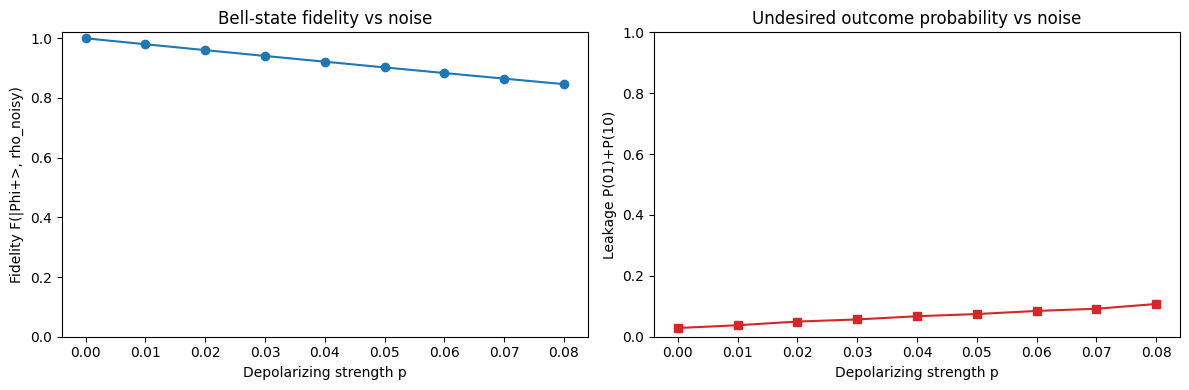


Monotonic trend check:
Fidelity decreases overall: True
Leakage increases overall: True


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(noise_strengths, fidelities, marker='o', color='tab:blue')
axes[0].set_xlabel('Depolarizing strength p')
axes[0].set_ylabel('Fidelity F(|Phi+>, rho_noisy)')
axes[0].set_ylim(0, 1.02)
axes[0].set_title('Bell-state fidelity vs noise')

axes[1].plot(noise_strengths, leakages, marker='s', color='tab:red')
axes[1].set_xlabel('Depolarizing strength p')
axes[1].set_ylabel('Leakage P(01)+P(10)')
axes[1].set_ylim(0, 1)
axes[1].set_title('Undesired outcome probability vs noise')

plt.tight_layout()
plt.show()

print("\nMonotonic trend check:")
print("Fidelity decreases overall:", all(fidelities[i] >= fidelities[i + 1] - 1e-6 for i in range(len(fidelities) - 1)))
print("Leakage increases overall:", all(leakages[i] <= leakages[i + 1] + 1e-6 for i in range(len(leakages) - 1)))

## Summary
| Metric | Definition | Ideal value | Observed trend with increasing noise |
|---|---|---|---|
| Fidelity | $\langle \Phi^+\|\rho\|\Phi^+\rangle$ | 1 | Decreases |
| Leakage | $P(01)+P(10)$ | 0 | Increases |

**Key takeaways:**
- Bell-state entanglement quality is directly quantifiable through fidelity.
- Measurement-space leakage complements fidelity as an experimentally accessible diagnostic.
- Even moderate depolarizing noise causes visible degradation in two-qubit correlations.
- Aer enables controlled error sweeps that isolate noise sensitivity before hardware execution.